# Проект: Статистический анализ данных

Цель проекта: Исследовать поведение пользователей с подспиской и без подписки. Обработаем данные, проведем исследовательский анализ данных.
В рамках исследования, мы обработаем три дата сета, проверим гипотезы:
1. Тратят ли пользователи с подпиской больше времени на поездки?
2. Проезжают ли пользователи за одну поездки больше чем норма эксплуатации?
3. Приносят ли пользователи без подписки большую сумму выручки ежемесячно?

## Загрузка данных

Загрузим дата сеты, с которыми будем работать и посмотрим на их структуру.

### Загрузка дата сетов

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

In [2]:
users = pd.read_csv("/datasets/users_go.csv")
rides = pd.read_csv("/datasets/rides_go.csv")
subscriptions = pd.read_csv("/datasets/subscriptions_go.csv")

Дата сеты загружены и записаны в переменные.

### Структура и общая информация о дата сетов

In [3]:
users.head(5)

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [5]:
rides.head(5)

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [6]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [7]:
subscriptions.head(5)

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [8]:
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


Вывод: Загрузили дата сеты, познакомились с их общей структурой, столбцами и хранимыми в них данными.

## Предобработка данных

Цель: Подготовим данные для анализа, приведем столбцы к нужному формату, создадим столбец с месяцем, обработаем пропущенные значения и дубликаты.

### Приведём столбец с датой к формату даты

In [9]:
rides['date'] = pd.to_datetime(rides['date'], format = '%Y-%m-%d')
print(rides['date'].dtype)

datetime64[ns]


### Создание столбца месяца

In [10]:
min_year = rides['date'].dt.year.min()
max_year = rides['date'].dt.year.max()
range_years = max_year - min_year


print(f"Размах лет:", range_years)

Размах лет: 0


In [11]:
rides['month'] = rides['date'].dt.month
rides['month'].head(3)

0    1
1    1
2    4
Name: month, dtype: int64

### Обработка дубликатов и пропущенных значений

In [12]:
miss_value_users = users.isnull().sum()
print(miss_value_users[miss_value_users > 0])

Series([], dtype: int64)


In [13]:
miss_value_rides = rides.isnull().sum()
print(miss_value_rides[miss_value_rides > 0])

Series([], dtype: int64)


In [14]:
miss_value_subscriptions = subscriptions.isnull().sum()
print(miss_value_subscriptions[miss_value_subscriptions > 0])

Series([], dtype: int64)


In [15]:
print(f'В таблице users явных дубликатов:', users.duplicated().sum()) 
print(f'В таблице rides явных дубликатов:', rides.duplicated().sum()) 
print(f'В таблице subscriptions явных дубликатов:', subscriptions.duplicated().sum()) 

В таблице users явных дубликатов: 31
В таблице rides явных дубликатов: 0
В таблице subscriptions явных дубликатов: 0


In [16]:
duplicates = users[users.duplicated()]
print(duplicates)

      user_id        name  age            city subscription_type
1534      293       Агата   26       Краснодар             ultra
1535       16      Амалия   27       Краснодар             ultra
1536      909  Константин   20    Екатеринбург              free
1537      403      Полина   19            Сочи             ultra
1538      908      Рустам   30          Тюмень              free
1539       43    Стефания   22            Омск             ultra
1540      127       Павел   25       Пятигорск             ultra
1541      659       Злата   27  Ростов-на-Дону             ultra
1542      204      Руслан   30       Пятигорск             ultra
1543      153      Герман   23          Москва             ultra
1544     1245      Регина   27       Пятигорск              free
1545      807   Александр   28    Екатеринбург              free
1546      924       Мария   23       Пятигорск              free
1547      635      Герман   21          Москва             ultra
1548      136     Марсель

Уберем явныем дубликаты.

In [17]:
users = users.drop_duplicates()
print(f'В таблице users явных дубликатов:', users.duplicated().sum()) 

В таблице users явных дубликатов: 0


Проверка на неявные дубликаты:

In [18]:
print(users['name'].unique())

['Кира' 'Станислав' 'Алексей' 'Константин' 'Адель' 'Регина' 'Игорь' 'Юрий'
 'Ян' 'Валерий' 'Агата' 'Марк' 'Ева' 'Антонина' 'Валерия' 'Амалия'
 'Даниил' 'Аделина' 'Святогор' 'Борис' 'Вероника' 'Ростислав' 'Назар'
 'Эдуард' 'Василий' 'Денис' 'Тамара' 'Николай' 'Эвелина' 'Федор' 'Руслан'
 'Иван' 'Любовь' 'Ярослава' 'Майя' 'Ильдар' 'Данила' 'Нина' 'Стефания'
 'Ясмина' 'Дмитрий' 'Александр' 'Одиссей' 'Арсений' 'Алла' 'Таисия'
 'Максим' 'Юлиана' 'Павел' 'Карина' 'Алиса' 'Лидия' 'Рамиль' 'Родион'
 'Ника' 'Оксана' 'Анастасия' 'Маргарита' 'Вера' 'Тимур' 'Никита' 'Лев'
 'Влад' 'Артур' 'Анна' 'Ольга' 'Вячеслав' 'Ксения' 'Виталина' 'Владислав'
 'Тамерлан' 'Амина' 'Вадим' 'Олеся' 'Зарина' 'Егор' 'Гордей' 'Лилия'
 'Святослав' 'Роберт' 'Амир' 'Влада' 'Богдан' 'Полина' 'Марат' 'Елисей'
 'Макар' 'Алина' 'Глеб' 'Андрей' 'Альбина' 'Людмила' 'Марсель' 'Милена'
 'Диана' 'Дарина' 'Данил' 'Артемий' 'Лиана' 'Альберт' 'Герман' 'Жанна'
 'Нелли' 'Евгения' 'Ариана' 'Самира' 'Захар' 'Эльвира' 'Екатерина' 'Инна'
 '

In [19]:
users['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

Вывод: Проверили данные на пропуски - их не оказалось. Обработали дубликаты, удалив явные дубликаты из дата сета users.

## Исследовательский анализ данных

Цель: Исследум и визуальзиуруем данные. 
Направления исследований:
1. Частота встречаемости городов.
2. Соотношение пользователей с подпиской и без подписки.
3. Возраст пользователей.
4. Расстояние, которое пользователь преодолел за одну поездку.
5. Продолжительсность поездок.


### Частота встречаемости городов

Text(0.5, 1.0, 'Частота встречаемости городов')

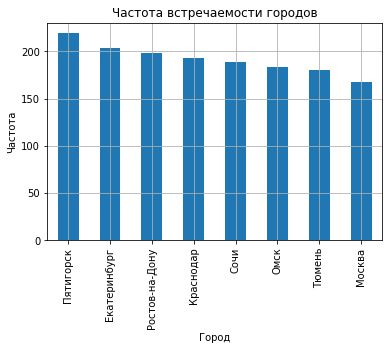

In [20]:
city_counts = users['city'].value_counts()
city_counts.plot(kind='bar')
plt.grid(True)
plt.xlabel('Город')
plt.ylabel('Частота')
plt.title('Частота встречаемости городов')

In [21]:
print(city_counts)

Пятигорск         219
Екатеринбург      204
Ростов-на-Дону    198
Краснодар         193
Сочи              189
Омск              183
Тюмень            180
Москва            168
Name: city, dtype: int64


Вывод: Наиболее часто встречаемый город - Пятигорск. Наименее встречаемый город - Москва.

### Соотношение пользователей с подпиской и без подписки

free     835
ultra    699
Name: subscription_type, dtype: int64


Text(0.5, 1.0, 'Соотношение пользователей с подпиской и без подписки')

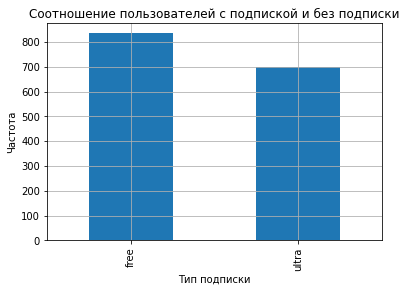

In [22]:
subscription_type_counts = users['subscription_type'].value_counts()
print(subscription_type_counts)
subscription_type_counts.plot(kind = 'bar')
plt.grid(True)
plt.xlabel('Тип подписки')
plt.ylabel('Частота')
plt.title('Соотношение пользователей с подпиской и без подписки')

free     54.432855
ultra    45.567145
Name: subscription_type, dtype: float64


Text(0, 0.5, '')

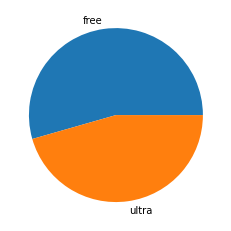

In [23]:
subscription_type_percentage = users['subscription_type'].value_counts(normalize=True) * 100
print(subscription_type_percentage)
subscription_type_percentage.plot(kind = 'pie')
plt.ylabel('')

Вывод: пользователей с подпиской free больше чем пользователей с подпиской ultra в соотношении 54.432855 к 45.567145.

### Возраст пользователей

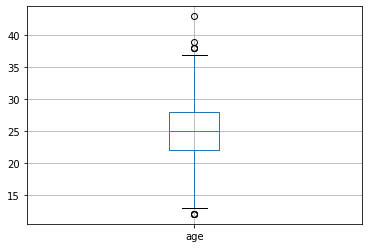

In [24]:
age_users = users[['age']].boxplot()

In [25]:
print(users['age'].median())

25.0


Вывод: Использовали метод boxplot, увидели что в данных есть выбросы, поэтому использовали медиану для опредения среднего возраста, который получился равен 25 годам.

### Расстояние, которое пользователь преодолел за одну поездку

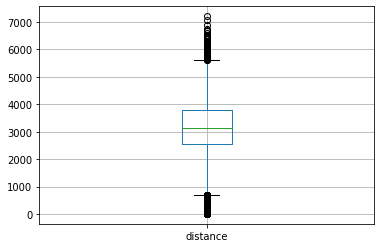

In [26]:
distance_boxplot = rides[['distance']].boxplot()

In [27]:
distance_for_user = pd.pivot_table(rides, index = 'user_id', values = 'distance', aggfunc = 'median')
print(distance_for_user)

            distance
user_id             
1        2806.504429
2        3105.086678
3        2858.693148
4        3373.276987
5        3244.021903
...              ...
1530     2724.331740
1531     2999.913238
1532     2615.477834
1533     2965.546552
1534     3434.290912

[1534 rows x 1 columns]


In [28]:
distance_for_user.median()

distance    3131.071202
dtype: float64

Вывод: Средняя дистанция на пользователя 3131.071202

### Продолжительность поездок

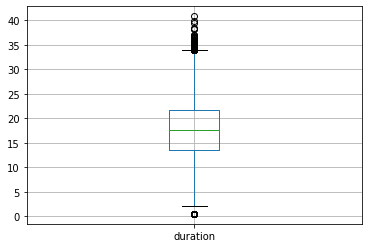

In [29]:
duration_boxplot = rides[['duration']].boxplot()

In [30]:
duration_for_user = pd.pivot_table(rides, index = 'user_id', values = 'duration', aggfunc = 'median')
print(duration_for_user)

          duration
user_id           
1        16.233505
2        18.779128
3        19.835873
4        20.723324
5        14.904990
...            ...
1530     16.207316
1531     18.308701
1532     14.846434
1533     19.772353
1534     18.343604

[1534 rows x 1 columns]


In [31]:
duration_for_user.median()

duration    17.743728
dtype: float64

Вывод: Среднее время в минутах 17.743728

Вывод: Провели исследовательский анализ данных, получили ответы на интересующие нас вопросы.
1. Наиболее часто встречаемый город - Пятигорск. Наименее встречаемый город - Москва.
2. Пользователей с подпиской free больше чем пользователей с подпиской ultra в соотношении 54.432855 к 45.567145.
3. Средний возраст получился равен 25 годам.
4. Средняя дистанция на пользователя 3131.071202 метр.
5. Среднее время в минутах 17.743728.

## Объединение данных

Цель: Создадим несколько новых датафремов для удобства работы.

In [32]:
print("Размер users:", users.shape)
print("Размер rides:", rides.shape)
print("Размер subscriptions:", subscriptions.shape)


Размер users: (1534, 5)
Размер rides: (18068, 5)
Размер subscriptions: (2, 4)


### Объединиv данные о пользователях, поездках и подписках в один датафрейм

In [33]:
df = users.merge(rides, on='user_id', how = 'left')
df = df.merge(subscriptions, on='subscription_type', how='left')
df.head(3)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199


In [34]:

print("Размер объединённого датафрейма:", df.shape)


Размер объединённого датафрейма: (18068, 12)


### Создадим ещё два датафрейма: c данными о пользователях без подписки и с данными о пользователях с подпиской.

In [35]:
df_with_sub = df.query('subscription_type == "ultra"')
df_without_sub = df.query('subscription_type != "ultra"')
df_with_sub.info()
df_without_sub.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6500 entries, 0 to 6499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            6500 non-null   int64         
 1   name               6500 non-null   object        
 2   age                6500 non-null   int64         
 3   city               6500 non-null   object        
 4   subscription_type  6500 non-null   object        
 5   distance           6500 non-null   float64       
 6   duration           6500 non-null   float64       
 7   date               6500 non-null   datetime64[ns]
 8   month              6500 non-null   int64         
 9   minute_price       6500 non-null   int64         
 10  start_ride_price   6500 non-null   int64         
 11  subscription_fee   6500 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 660.2+ KB
<class 'pandas.core.frame.DataFrame'>
In

In [36]:
df_with_sub.head(5)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


In [37]:
df_without_sub.head(5)

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0


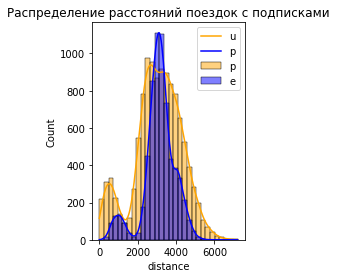

In [38]:
plt.subplot(1, 2, 1)
sns.histplot(df, x="distance", hue="subscription_type", kde=True, bins=30, palette=["blue", "orange"])
plt.title("Распределение расстояний поездок с подписками")
plt.legend("upper right")

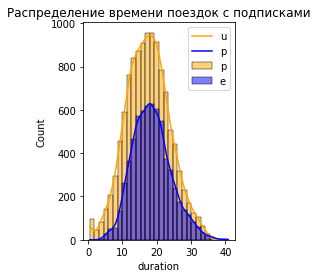

In [39]:
plt.subplot(1, 2, 1)
sns.histplot(df, x="duration", hue="subscription_type", kde=True, bins=30, palette=["blue", "orange"])
plt.title("Распределение времени поездок с подписками")
plt.legend("upper right")

Вывод: Создали несколько датафреймов для работы, построили график распределения дистатнции и времени для двух групп пользователей, с подпиской и без подписки.

## Подсчёт выручки

Цель: Посчитаем показатели покаждому пользователю. Вычислим суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц, а также помесячную выручку, которую принёс каждый пользователь.

### Создадим датафрейм с агрегированными значениями по каждому полбзователю

In [40]:

df['rounded_duration'] = np.ceil(df['duration'])


df['ride_revenue'] = np.where(
    df['subscription_type'] == 'ultra',  
    df['rounded_duration'] * 6,  
    df['rounded_duration'] * 8 + 50  
)


df_agg = df.groupby(['user_id', 'month']).agg(
    total_distance=('distance', 'sum'),
    total_trips=('user_id', 'count'),
    total_duration=('duration', 'sum'),
    total_revenue=('ride_revenue', 'sum'),  
    subscription_fee=('subscription_type', lambda x: 199 if 'ultra' in x.values else 0)  \
).reset_index()


df_agg['total_monthly_revenue'] = df_agg['total_revenue'] + df_agg['subscription_fee']

df_agg.head(100)


,user_id,month,total_distance,total_trips,total_duration,total_revenue,subscription_fee,total_monthly_revenue
0,1,1,7027.511294,2,41.416640,252.0,199,451.0
1,1,4,754.159807,1,6.232113,42.0,199,241.0
2,1,8,6723.470560,2,44.776802,276.0,199,475.0
3,1,10,5809.911100,2,31.578017,192.0,199,391.0
4,1,11,7003.499363,3,53.397424,336.0,199,535.0
...,...,...,...,...,...,...,...,...
95,15,9,3632.400668,1,24.621503,150.0,199,349.0
96,15,10,3647.651942,1,21.421863,132.0,199,331.0
97,15,11,671.851433,1,12.031109,78.0,199,277.0
98,16,2,850.321732,1,13.125804,84.0,199,283.0


In [41]:
df_agg

,user_id,month,total_distance,total_trips,total_duration,total_revenue,subscription_fee,total_monthly_revenue
0,1,1,7027.511294,2,41.416640,252.0,199,451.0
1,1,4,754.159807,1,6.232113,42.0,199,241.0
2,1,8,6723.470560,2,44.776802,276.0,199,475.0
3,1,10,5809.911100,2,31.578017,192.0,199,391.0
4,1,11,7003.499363,3,53.397424,336.0,199,535.0
...,...,...,...,...,...,...,...,...
11326,1534,6,3409.468534,2,24.812678,308.0,0,308.0
11327,1534,8,7622.453034,2,47.205960,484.0,0,484.0
11328,1534,9,4928.173852,1,22.560373,234.0,0,234.0
11329,1534,11,13350.015305,4,76.342174,824.0,0,824.0


Вывод: Посчитали информацию по каждому пользователю в разрезе месяца

## Проверка гипотез

Цель: Проверить несколько гипотез. 

1. Тратят ли пользователи с подпиской больше времени на поездки?
2. Проезжают ли пользователи за одну поездки больше чем норма эксплуатации?
3. Приносят ли пользователи без подписки большую сумму выручки ежемесячно?

### Тратят ли пользователи с подпиской больше времени на поездки?

Нулевая гипотеза (H₀): Нет значимой разницы во времени поездок между подписчиками и обычными пользователями. Среднее время поездки для обеих групп одинаково.

Альтернативная гипотеза (H₁): Пользователи с подпиской тратят больше времени на поездки по сравнению с обычными пользователями.

In [42]:

t_stat, p_value = stats.ttest_ind(df_with_sub['duration'], df_without_sub['duration'], alternative = 'greater')

print(f"T-test: p-value = {p_value:}")

alpha = 0.05

if p_value < alpha:
    print("Пользователи с подпиской тратят больше времени на поездки (гипотеза подтверждена).")
else:
    print("Нет значимой разницы во времени поездок между подписчиками и обычными пользователями.")

T-test: p-value = 1.2804098316645618e-34
Пользователи с подпиской тратят больше времени на поездки (гипотеза подтверждена).


### Проезжают ли пользователи за одну поездки больше чем норма эксплуатации?

Нулевая гипотеза (H₀): Среднее расстояние поездки для пользователей с подпиской не превышает 3130 метров.

Альтернативная гипотеза (H₁): Среднее расстояние поездки для пользователей с подпиской больше 3130 метров.

In [43]:
ultra_users_distances = df_with_sub['distance']

mu = 3130

t_stat, p_value = stats.ttest_1samp(ultra_users_distances, mu)

p_value = p_value/2

print(f"T-test: p-value = {p_value}")


alpha = 0.05

if p_value < alpha:
    print("Среднее расстояние для пользователей с подпиской больше 3130 метров (гипотеза отвергнута).")
else:
    print("Среднее расстояние для пользователей с подпиской не превышает 3130 метров (гипотеза подтверждена).")

T-test: p-value = 0.08046311521502146
Среднее расстояние для пользователей с подпиской не превышает 3130 метров (гипотеза подтверждена).


### Приносят ли пользователи без подписки большую сумму выручки ежемесячно?

Нулевая гипотеза (H₀): Нет значимой разницы в помесячной выручке между пользователями с подпиской и без подписки.

Альтернативная гипотеза (H₁): Средняя помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки.

In [44]:
ultra_users_revenue = df_agg[df_agg['subscription_fee'] == 199]['total_monthly_revenue']
non_ultra_users_revenue = df_agg[df_agg['subscription_fee'] == 0]['total_monthly_revenue']

t_stat, p_value = stats.ttest_ind(ultra_users_revenue, non_ultra_users_revenue, alternative='greater', equal_var=False)

print(f"T-test: p-value = {p_value}")

alpha = 0.05
if p_value < alpha:
    print("Средняя помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки (гипотеза подтверждена).")
else:
    print("Нет значимой разницы в помесячной выручке между пользователями с подпиской и без подписки.")

T-test: p-value = 8.874140893976874e-40
Средняя помесячная выручка от пользователей с подпиской выше, чем от пользователей без подписки (гипотеза подтверждена).


### Гипотеза

Для проверки гипотезы о том, что обновление серверов привело к значимому снижению количества обращений в техподдержку, можно использовать парный t-тест (t-test для зависимых выборок). ttest_rel()

## Вывод

В ходе исследования мы подготовили данные, обработали пропущенные значения и дубликаты, а также привели столбцы к нужному формату. Далее мы провели исследовательский анализ данных и сделали следущие выводы:

География пользователей: Наиболее часто встречаемый город – Пятигорск, наименее встречаемый – Москва.

Распределение подписок: Пользователей с подпиской free больше, чем с подпиской ultra, в соотношении 54.43% к 45.57%.

Возраст пользователей: Средний возраст пользователей – 25 лет (рассчитан с учетом выбросов).

Дистанция поездок: В среднем пользователь преодолевает 3131.07 метра за одну поездку.

Время поездок: Средняя продолжительность поездки – 17.74 минуты.

Затем мы рассчитали индивидуальные показатели для каждого пользователя, включая суммарное расстояние, количество поездок, общее время и месячную выручку.

При проверке гипотез было установлено:

Пользователи с подпиской проводят больше времени в поездке – гипотеза подтверждена.

Средняя дистанция поездки пользователей с подпиской не превышает 3130 метров – гипотеза подтверждена.

Пользователи с подпиской приносят большую месячную выручку, чем пользователи без подписки – гипотеза подтверждена.


Рекомендации для бизнеса:

1. Ориентироваться на Пятигорск - так как это самый популярный город, нужно увеличивать в нём объёмы, проводить маркетинговые акции.
2. Увеличить количество пользователей с подпиской - количество пользователей без подписки больше, есть куда расти. 